In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/digit-recognizer/sample_submission.csv
/kaggle/input/competitions/digit-recognizer/train.csv
/kaggle/input/competitions/digit-recognizer/test.csv


In [3]:
df = pd.read_csv("/kaggle/input/competitions/digit-recognizer/train.csv")

In [4]:
df.shape

(42000, 785)

In [5]:
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
df.sample(1)

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
33477,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
import matplotlib.pyplot as plt

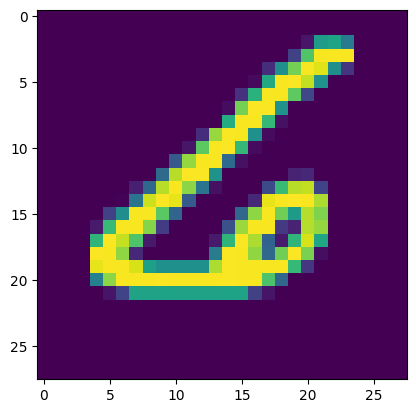

In [7]:
plt.imshow(df.iloc[25100, 1:].values.reshape(28, 28))
plt.show()

In [8]:
X = df.iloc[:, 1:]
y = df.iloc[:, 0]

In [9]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 19)

In [10]:
X_train.shape

(33600, 784)

In [10]:
from sklearn.neighbors import KNeighborsClassifier

In [11]:
knn = KNeighborsClassifier()

In [14]:
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [15]:
import time
start = time.time()
y_pred = knn.predict(X_test)
print(time.time() - start)

12.782394886016846


In [16]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.9677380952380953

In [17]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [18]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit(X_test)

In [12]:
#pca
from sklearn.decomposition import PCA
pca = PCA(n_components = 100)

In [20]:
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

In [21]:
X_train_pca.shape
#numbers of column has been decreased

(33600, 100)

In [24]:
knn = KNeighborsClassifier()

In [26]:
knn.fit(X_train_pca, y_train)

KNeighborsClassifier()

In [28]:
import time
start = time.time()
y_pred_pca = knn.predict(X_test_pca)
print(time.time() - start)

1.7274346351623535


In [29]:
accuracy_score(y_test, y_pred_pca)

0.9694047619047619

In [ ]:
for i in range(1, 785):
    pca = PCA(n_components = i)

    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)

    knn = KNeighborsClassifier()

    knn.fit(X_train_pca, y_train)

    y_pred_pca = knn.predict(X_test_pca)

    print(accuracy_score(y_test, y_pred_pca))

In [18]:
#visualization
#transforming to a 2D co-ordinate system
pca = PCA(n_components = 2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

In [19]:
X_train_pca

array([[ -956.07215387,   513.58859974],
       [ -784.75907597,  -324.3176079 ],
       [ -627.07597213,  -502.04028243],
       ...,
       [  411.92879974,   300.82113277],
       [ -949.57646388,   465.66678283],
       [  456.34403983, -1068.96340797]])

In [21]:
import plotly.express as px
y_train_pca = y_train.astype(str)
fig = px.scatter(x = X_train_pca[:, 0],
                y = X_train_pca[:, 1],
                color = y_train_pca,
                color_discrete_sequence = px.colors.qualitative.G10)
fig.show()

In [22]:
#visualization
#transforming to a 3D co-ordinate system
pca = PCA(n_components = 3)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

In [23]:
X_train_pca

array([[ -956.07215387,   513.58859974,   -85.39430786],
       [ -784.75907597,  -324.3176079 ,   -81.86763056],
       [ -627.07597213,  -502.04028243,   198.83375416],
       ...,
       [  411.92879974,   300.82113277,  -578.66818688],
       [ -949.57646388,   465.66678283,   -63.82382937],
       [  456.34403983, -1068.96340797,  -339.38514992]])

In [26]:
import plotly.express as px
y_train_pca = y_train.astype(str)
fig = px.scatter_3d(x = X_train_pca[:, 0],
                y = X_train_pca[:, 1],
                 z = X_train_pca[:, 2],
                color = y_train_pca,
                color_discrete_sequence = px.colors.qualitative.G10)
fig.show()

In [28]:
#this is the eigen values
pca.explained_variance_

array([336619.96870279, 245347.34442333, 210205.24485006])

In [31]:
#eigen vectors
pca.components_

array([[-0., -0., -0., ..., -0., -0., -0.],
       [-0., -0., -0., ..., -0., -0., -0.],
       [-0., -0., -0., ..., -0., -0., -0.]])

In [32]:
pca = PCA(n_components = None)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

In [33]:
pca.explained_variance_

array([3.36619969e+05, 2.45347344e+05, 2.10205245e+05, 1.84592669e+05,
       1.68653636e+05, 1.48169004e+05, 1.12755994e+05, 9.92864532e+04,
       9.52486931e+04, 8.01863301e+04, 7.20140546e+04, 7.07127656e+04,
       5.86261027e+04, 5.82183845e+04, 5.40269047e+04, 5.11557845e+04,
       4.54769297e+04, 4.39053691e+04, 4.06644475e+04, 3.93572446e+04,
       3.67832071e+04, 3.48432352e+04, 3.31583393e+04, 3.12337768e+04,
       3.04226496e+04, 2.89589267e+04, 2.79619452e+04, 2.66569123e+04,
       2.53989722e+04, 2.35571678e+04, 2.26163032e+04, 2.19656349e+04,
       2.06002502e+04, 2.02669136e+04, 1.93082243e+04, 1.85207110e+04,
       1.75770652e+04, 1.67031682e+04, 1.62955266e+04, 1.60173357e+04,
       1.56082950e+04, 1.51922075e+04, 1.43847588e+04, 1.36342979e+04,
       1.32581005e+04, 1.28674552e+04, 1.24111638e+04, 1.20009272e+04,
       1.15886567e+04, 1.09985374e+04, 1.08324400e+04, 1.05688546e+04,
       1.00981423e+04, 9.84410984e+03, 9.63326589e+03, 9.25831584e+03,
      

In [37]:
np.cumsum(pca.explained_variance_ratio_)

array([0.0980168 , 0.1694569 , 0.23066434, 0.28441392, 0.33352239,
       0.37666615, 0.40949837, 0.43840855, 0.466143  , 0.48949161,
       0.51046062, 0.53105072, 0.54812144, 0.56507343, 0.58080495,
       0.59570047, 0.60894241, 0.62172675, 0.6335674 , 0.64502742,
       0.65573793, 0.66588356, 0.67553859, 0.68463322, 0.69349167,
       0.70192392, 0.71006586, 0.7178278 , 0.72522346, 0.73208282,
       0.73866822, 0.74506416, 0.75106253, 0.75696384, 0.762586  ,
       0.76797885, 0.77309693, 0.77796055, 0.78270547, 0.78736939,
       0.7919142 , 0.79633786, 0.8005264 , 0.80449643, 0.80835692,
       0.81210365, 0.81571753, 0.81921195, 0.82258633, 0.82578888,
       0.82894306, 0.83202049, 0.83496087, 0.83782727, 0.84063228,
       0.84332811, 0.84597723, 0.84853344, 0.85107175, 0.85353992,
       0.85592736, 0.85830147, 0.86056828, 0.86279264, 0.86494467,
       0.86699896, 0.86901545, 0.87097499, 0.87291123, 0.8748013 ,
       0.87666173, 0.87848289, 0.8802502 , 0.88196601, 0.88362

In [36]:
pca.components_

array([[-0., -0., -0., ..., -0., -0., -0.],
       [-0., -0., -0., ..., -0., -0., -0.],
       [-0., -0., -0., ..., -0., -0., -0.],
       ...,
       [-0., -0., -0., ..., -0., -0., -0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [-0., -0., -0., ..., -0., -0., -0.]])

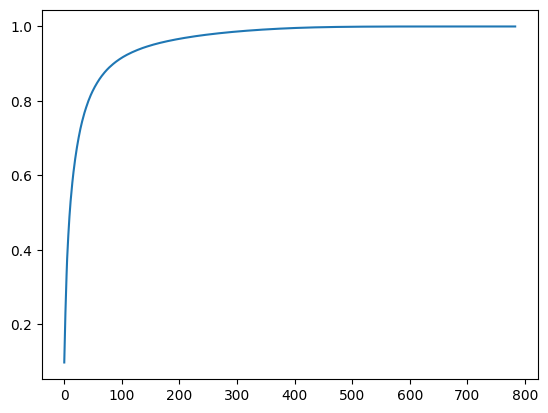

In [38]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))